# 04 — Apply topic labels and build v3 corpus

Reads the hand-edited `data/topic_labels.csv` from notebook 03's labelling step, joins it onto v2 (with LDA topic info from `intermediate.parquet`), filters to the political-adjacent corpus, validates, and writes v3.

This notebook is **the consumer of the hand-labelling step**. Run it any time you tweak `topic_labels.csv` — the expensive LDA fit doesn't need to rerun (that's notebook 03's job).

**Workflow**:

1. Notebooks 01–03 — build v2, fit LDA, write `topic_terms.csv`.
2. **You** — edit `topic_terms.csv` → `topic_labels.csv` with `label` and `category` columns filled in.
3. **This notebook (04)** — join labels, filter, write v3.

**Filter rule**:

- KEEP `match_type ∈ {candidate, party_org}` — registered party advertising.
- KEEP `match_type IS NULL AND category ≠ 'noise'` — political-adjacent advocacy passed the LDA + hand-labelling round.
- DROP `match_type = 'government'` — out of scope.
- DROP residual with `category = 'noise'` or no topic at all.

## 1. Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, broadcast, desc

spark = SparkSession.builder \
    .appName('FB_API_v3_build') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/14 04:17:34 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## 2. Paths

In [2]:
V2_PATH           = '/user/s3348393/main/preprocessing/v2/parquet'
INTERMEDIATE_PATH = '/user/s3348393/main/preprocessing/v3/intermediate_parquet'
V3_PATH           = '/user/s3348393/main/preprocessing/v3/parquet'
TOPIC_LABELS_CSV  = '../data/topic_labels.csv'

## 3. Join labels and topic info onto v2

Three inputs combined:

1. `v2` parquet (one row per ad via `ad_seq_no = 1`) — every ad with `match_type` and `political_party`.
2. `intermediate` parquet (residual subset only, with `topic_id` + `topicDistribution`) — from notebook 03.
3. `topic_labels.csv` — hand-edited labels with `topic_label` and `category`.

Left-join so every v2 row gets the LDA columns *if* it was in the residual corpus, otherwise null. Cache the result — every cell below scans it.

In [3]:
import pandas as pd

v2 = spark.read.parquet(V2_PATH).filter(col('ad_seq_no') == 1)

intermediate = spark.read.parquet(INTERMEDIATE_PATH) \
    .select('id', 'topic_id', 'topicDistribution', 'body')

# topic_labels.csv lives on the edge-node filesystem, not HDFS — load via pandas
# and createDataFrame so Spark doesn't try to read it from HDFS.
labels_pdf = pd.read_csv(TOPIC_LABELS_CSV)[['topic_id', 'label', 'category']]
labels = spark.createDataFrame(labels_pdf) \
    .withColumnRenamed('label', 'topic_label')

classified = v2 \
    .join(intermediate, 'id', 'left') \
    .join(broadcast(labels), 'topic_id', 'left') \
    .cache()

print(f'All ads (ad_seq_no=1): {classified.count():,}')
print(f'  with topic info:    {classified.filter(col("topic_id").isNotNull()).count():,}')
print(f'  without topic info: {classified.filter(col("topic_id").isNull()).count():,}')

26/05/14 04:17:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


All ads (ad_seq_no=1): 151,578
  with topic info:    96,286
  without topic info: 55,292


## 4. Distribution sanity check

Confirm the join produced sensible counts. Non-residual rows (candidate / party_org / government) should have null `category`; residual rows (`match_type IS NULL`) should split across the labelled categories.

In [4]:
print('match_type × category:')
classified.groupBy('match_type', 'category').count() \
    .orderBy('match_type', 'category') \
    .show(50, truncate=False)

# Belt-and-braces: did any topic_id end up unmatched in the labels CSV?
unmatched = classified.filter(col('topic_id').isNotNull() & col('topic_label').isNull()).count()
print(f'Rows with topic_id but no topic_label (should be 0): {unmatched}')

match_type × category:
+----------+-------------------+-----+
|match_type|category           |count|
+----------+-------------------+-----+
|NULL      |NULL               |9528 |
|NULL      |climate            |33962|
|NULL      |cost_of_living     |3258 |
|NULL      |humanitarian_rights|14331|
|NULL      |noise              |1056 |
|NULL      |political_advocacy |43679|
|candidate |NULL               |20644|
|government|NULL               |1188 |
|party_org |NULL               |23932|
+----------+-------------------+-----+

Rows with topic_id but no topic_label (should be 0): 0


## 5. Apply the political-corpus filter

Drop government rows, residual noise-labelled rows, and residual rows that didn't make the LDA corpus (no topic). What survives is the analysis-ready political-adjacent corpus.

In [5]:
before = classified.count()

v3_candidate = classified.filter(
    col('match_type').isin('candidate', 'party_org')
    | (col('match_type').isNull() & col('category').isNotNull() & (col('category') != 'noise'))
)
v3_candidate.cache()
after = v3_candidate.count()

print(f'Before filter: {before:,}')
print(f'After filter:  {after:,}')
print(f'Dropped:       {before - after:,}  ({100 * (before - after) / before:.1f}%)')

print('\nKept rows by match_type × category:')
v3_candidate.groupBy('match_type', 'category').count() \
    .orderBy('match_type', 'category') \
    .show(50, truncate=False)

Before filter: 151,578
After filter:  139,806
Dropped:       11,772  (7.8%)

Kept rows by match_type × category:
+----------+-------------------+-----+
|match_type|category           |count|
+----------+-------------------+-----+
|NULL      |climate            |33962|
|NULL      |cost_of_living     |3258 |
|NULL      |humanitarian_rights|14331|
|NULL      |political_advocacy |43679|
|candidate |NULL               |20644|
|party_org |NULL               |23932|
+----------+-------------------+-----+



### 5.1 Composition donut

Visualise where the 151,578 unique ads end up: the four kept residual categories, the two registered-political buckets (`candidate`, `party_org`), and a single `dropped` slice covering everything the filter excluded (government, noise topics, residual with no topic at all).

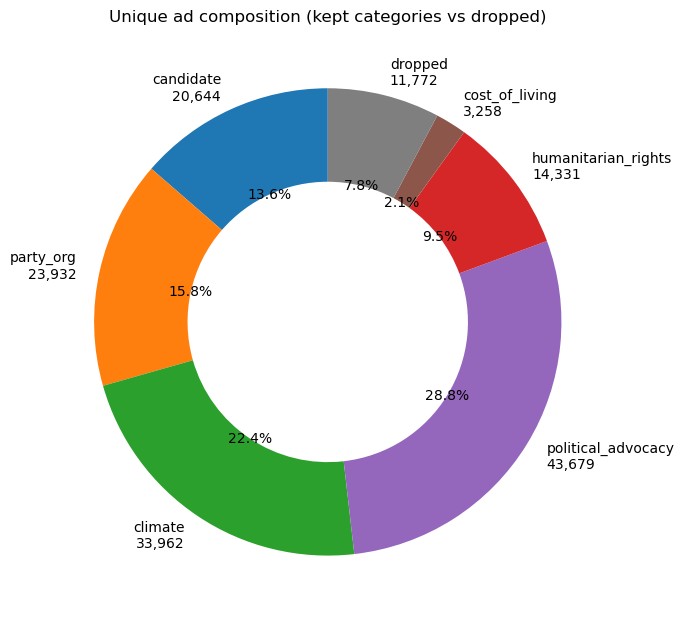

In [6]:
import matplotlib.pyplot as plt

# Kept slices come from v3_candidate (already grouped by match_type × category above).
# match_type ∈ {candidate, party_org} → slice keyed by match_type;
# match_type IS NULL → slice keyed by category.
kept_pdf = v3_candidate.groupBy('match_type', 'category').count().toPandas()

slices = {}
for _, r in kept_pdf.iterrows():
    key = r['match_type'] if r['match_type'] in ('candidate', 'party_org') else r['category']
    slices[key] = slices.get(key, 0) + int(r['count'])

# Single 'dropped' slice = everything filter excluded (government + noise + residual with no topic).
slices['dropped'] = classified.count() - v3_candidate.count()

order = ['candidate', 'party_org',
         'climate', 'political_advocacy', 'humanitarian_rights', 'cost_of_living',
         'dropped']
colors = {
    'candidate':           '#1f77b4',
    'party_org':           '#ff7f0e',
    'climate':             '#2ca02c',
    'political_advocacy':  '#9467bd',
    'humanitarian_rights': '#d62728',
    'cost_of_living':      '#8c564b',
    'dropped':             '#7f7f7f',
}

sizes  = [slices[k] for k in order]
labels = [f'{k}\n{slices[k]:,}' for k in order]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    sizes,
    labels=labels,
    colors=[colors[k] for k in order],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4),
)
ax.set_title('Unique ad composition (kept categories vs dropped)')
plt.tight_layout()
plt.show()

## 6. Validation — false positives and false negatives

**False positives** (we INCLUDED these — do they look political?): top-spend ads from each kept category. A commercial advertiser surfacing at the top means the LDA labelling needs another pass.

**False negatives** (we EXCLUDED these — were any actually political?): top advertisers from dropped (`noise`) topics, plus top advertisers from residual rows with no topic. A real political advertiser surfacing means that topic was mislabelled or that byline was over-filtered upstream.

In [7]:
# --- False positives: top-spend ads in each kept category ---
print('=== FP check: top-spend per kept category ===')
for cat in ['climate', 'humanitarian_rights', 'political_advocacy', 'cost_of_living']:
    print(f'\n--- {cat} ---')
    v3_candidate.filter((col('category') == cat) & col('spend_mid').isNotNull()) \
        .orderBy(desc('spend_mid')) \
        .select('page_name', 'bylines', 'topic_label', 'spend_mid') \
        .show(5, truncate=60)

# Also: top-spend candidate + party_org
print('\n=== FP check: top-spend candidate + party_org ads ===')
v3_candidate.filter(col('match_type').isin('candidate', 'party_org') & col('spend_mid').isNotNull()) \
    .orderBy(desc('spend_mid')) \
    .select('page_name', 'bylines', 'political_party', 'match_type', 'spend_mid') \
    .show(10, truncate=60)

# --- False negatives: top bylines in dropped noise topics ---
print('\n=== FN check: top bylines in DROPPED noise-labelled topics ===')
classified.filter(col('category') == 'noise') \
    .groupBy('topic_label', 'bylines').count() \
    .orderBy(desc('count')) \
    .show(20, truncate=80)

# --- False negatives: top bylines in residual with no topic_id ---
print('\n=== FN check: top bylines in residual with NO topic_id (empty body / non-English / commercial bylines) ===')
classified.filter(col('match_type').isNull() & col('topic_id').isNull() & col('bylines').isNotNull()) \
    .groupBy('bylines').count() \
    .orderBy(desc('count')) \
    .show(20, truncate=80)

=== FP check: top-spend per kept category ===

--- climate ---
+----------------------------------+---------------------------------+----------------------+---------+
|                         page_name|                          bylines|           topic_label|spend_mid|
+----------------------------------+---------------------------------+----------------------+---------+
|                             Shell|                            Shell| climate_global_action| 424999.5|
|   Koffels Solicitors & Barristers|Koffels Solicitors and Barristers|  plastic_marine_waste|  54999.5|
|The Uluru Statement from the Heart|      Indigenous Law Centre, UNSW|anti_woodside_petition|  54999.5|
|      Greenpeace Australia Pacific|     Greenpeace Australia Pacific| wildlife_conservation|  54999.5|
|  Australian Cyber Security Centre| Australian Cyber Security Centre|   clean_tech_minerals|  42499.5|
+----------------------------------+---------------------------------+----------------------+---------+
o

## 7. Write v3

Drop intermediate columns we don't need downstream (`body`, `topicDistribution`). Write partitioned by `category` so notebook 05 can read subsets selectively.

In [ ]:
intermediate_cols = ['body', 'topicDistribution']
v3_out = v3_candidate.drop(*[c for c in intermediate_cols if c in v3_candidate.columns])

spark.conf.set('spark.sql.parquet.output.committer.class',
               'org.apache.parquet.hadoop.ParquetOutputCommitter')
v3_out.write \
    .option('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .partitionBy('category') \
    .parquet(V3_PATH, mode='overwrite')

print(f'Wrote {V3_PATH}')

# Round-trip
rt = spark.read.parquet(V3_PATH)
print(f'\nRound-trip rows: {rt.count():,}')
rt.printSchema()

Wrote /user/s3348393/main/preprocessing/v3/parquet



Round-trip rows: 139,806
root
 |-- topic_id: long (nullable = true)
 |-- id: string (nullable = true)
 |-- page_id: string (nullable = true)
 |-- page_name: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- ad_creation_date: date (nullable = true)
 |-- ad_delivery_start_date: date (nullable = true)
 |-- ad_delivery_stop_date: date (nullable = true)
 |-- creative_bodies: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- creative_link_captions: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- creative_link_descs: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- creative_link_titles: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- currency: string (nullable = true)
 |-- languages: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- publisher_platforms: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- de

26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_26_7 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_26_8 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_81_0 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_26_6 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_81_5 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_26_9 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_81_7 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_26_12 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_81_9 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_81_3 !
26/05/14 04:37:57 WARN BlockManagerMasterEndpoint: No more replicas a